# Image Super Resolution using ESRGAN

## 🧠 What is ESRGAN?

ESRGAN is a type of GAN (Generative Adversarial Network) that turns low-quality, blurry images into sharp, high-resolution ones.

Think of it like photo enhancement magic — it takes a pixelated image and makes it look much clearer and more detailed.



---



### 🧩 Real-Life Analogy

Imagine:
	•	You have a tiny, blurry passport photo.
	•	You give it to a smart artist (the ESRGAN generator) and ask:

“Please draw what this person really looks like.”

The artist:
	•	Fills in missing details like eyelashes, hair texture, or shirt pattern — based on what real people usually look like.
	•	A critic (discriminator) judges whether the result looks like a real high-quality photo.

They train together until the artist gets so good that the critic can’t tell the difference.

---

## 🔍 What Makes ESRGAN Special?

Compared to earlier models like SRGAN, ESRGAN:
-	Adds more realistic textures.
-	Keeps sharp edges (no more overly smooth results).
-	Uses something called Residual-in-Residual Dense Blocks (RRDB) – sounds technical, but it just means better “memory” and pattern understanding while enhancing details.
-	Focuses on perceptual quality (how natural it looks, not just pixel accuracy).

---

## 🖼️ Example Result:

You give ESRGAN a blurry 64×64 image of a face → it outputs a clear, detailed 256×256 image that looks like a real photo.

- **PREPARING ENVIRONMENT**

In [1]:
import os
import time
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
os.environ['TFHUB_DOWNLOAD_PROGRESS'] = 'True'

In [2]:
!wget "https://user-images.githubusercontent.com/12981474/40157448-eff91f06-5953-11e8-9a37-f6b5693fa03f.png" -O original.png

--2026-09-28 06:36:27--  https://user-images.githubusercontent.com/12981474/40157448-eff91f06-5953-11e8-9a37-f6b5693fa03f.png
Resolving user-images.githubusercontent.com (user-images.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to user-images.githubusercontent.com (user-images.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34146 (33K) [image/png]
Saving to: ‘original.png’

original.png        100%[===================>]  33.35K  --.-KB/s    in 0.002s  

2026-09-28 06:36:27 (13.8 MB/s) - ‘original.png’ saved [34146/34146]



In [3]:
# Declaring Constants
IMAGE_PATH = "original.png"
SAVE_MODEL_PATH = "https://tfhub.dev/captain-pool/esrgan-tf2/1"

- **Defining Helper Functions**

In [6]:
def preprocess_img(image_path):
  """ Loads image from path and preprocesses to make it model ready
      Args:
        image_path: Path to the image file
  """
  hr_image = tf.image.decode_image(tf.io.read_file(image_path))
  # If PNG, remove the alpha channel. The model only supports
  # images with 3 color channels.
  if hr_image.shape[-1] == 4:
    hr_image = hr_image[...,:-1]
  hr_size = (tf.convert_to_tensor(hr_image.shape[:-1]) // 4) * 4
  hr_image = tf.image.crop_to_bounding_box(hr_image,0,0,hr_size[0],hr_size[1])
  hr_image = tf.cast(hr_image,tf.float32)
  return tf.expand_dims(hr_image,0)

def save_image(image, filename):
  """
    Saves unscaled Tensor Images.
    Args:
      image: 3D image tensor. [height, width, channels]
      filename: Name of the file to save.
  """
  if not isinstance(image,Image.Image):
    image = tf.clip_by_value(image,0,255)
    image = Image.fromarray(tf.cast(image,tf.uint8).numpy())
  image.save("%s.jpg"% filename)
  print("Saved as %s.jpg"% filename)

In [4]:
%matplotlib inline
def plot_image(image, title=""):
  """
    Plots images from image tensors.
    Args:
      image: 3D image tensor. [height, width, channels].
      title: Title to display in the plot.
  """
  image = np.asarray(image)
  image = tf.clip_by_value(image, 0, 255)
  image = Image.fromarray(tf.cast(image, tf.uint8).numpy())
  plt.imshow(image)
  plt.axis("off")
  plt.title(title)

In [7]:
hr_image = preprocess_img(IMAGE_PATH)
hr_image.shape

TensorShape([1, 120, 124, 3])

In [8]:
tf.squeeze(hr_image).shape

TensorShape([120, 124, 3])

#### Performing Super Resolution of images loaded from path

Saved as Original Image.jpg


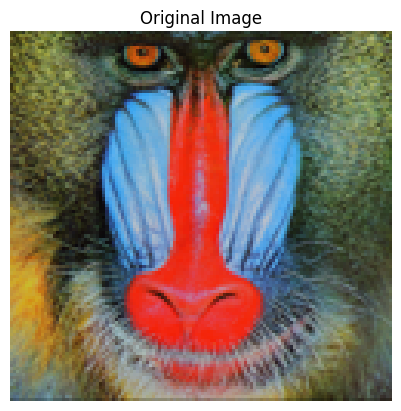

In [9]:
# Plotting Original Resolution image
plot_image(tf.squeeze(hr_image), title="Original Image")
save_image(tf.squeeze(hr_image), filename="Original Image")

In [10]:
import tensorflow_hub as hub
model = hub.load(SAVE_MODEL_PATH)

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Downloaded https://tfhub.dev/captain-pool/esrgan-tf2/1, Total size: 20.60MB



In [11]:
start = time.time()
fake_image = model(hr_image)
fake_image = tf.squeeze(fake_image)
print("Time Taken: %f" % (time.time() - start))

Time Taken: 2.340936


Saved as Super Resolution.jpg


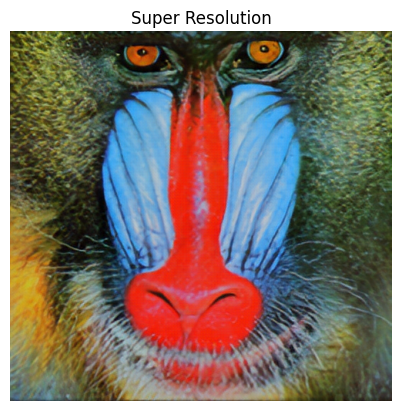

In [12]:
# Plotting Super Resolution Image
plot_image(tf.squeeze(fake_image), title="Super Resolution")
save_image(tf.squeeze(fake_image), filename="Super Resolution")

#Evaluating Performance of the Model

In [13]:
!wget "https://lh4.googleusercontent.com/-Anmw5df4gj0/AAAAAAAAAAI/AAAAAAAAAAc/6HxU8XFLnQE/photo.jpg64" -O test.jpg
IMAGE_PATH = "test.jpg"

--2026-09-28 07:02:23--  https://lh4.googleusercontent.com/-Anmw5df4gj0/AAAAAAAAAAI/AAAAAAAAAAc/6HxU8XFLnQE/photo.jpg64
Resolving lh4.googleusercontent.com (lh4.googleusercontent.com)... 74.125.137.132, 2607:f8b0:4023:c03::84
Connecting to lh4.googleusercontent.com (lh4.googleusercontent.com)|74.125.137.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85465 (83K) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>]  83.46K  --.-KB/s    in 0.04s   

2026-09-28 07:02:24 (2.05 MB/s) - ‘test.jpg’ saved [85465/85465]



In [17]:
# Defining helper functions
def downscale_image(image):
  """
      Scales down images using bicubic downsampling.
      Args:
          image: 3D or 4D tensor of preprocessed image
  """
  image_size = []
  if len(image.shape) == 3:
    image_size = [image.shape[1],image.shape[0]]
  else:
    raise ValueError("Dimension mismatch. Can work only on single image")

  image = tf.squeeze(
      tf.cast(
          tf.clip_by_value(image,0,255),tf.uint8
      )
  )
  lr_image = np.asarray(
      Image.fromarray(image.numpy())
      .resize([image_size[0]//4,image_size[1]//4],
              Image.BICUBIC)
  )
  lr_image = tf.expand_dims(lr_image,0)
  lr_image = tf.cast(lr_image,tf.float32)
  return lr_image

In [18]:
hr_image = preprocess_img(IMAGE_PATH)

In [19]:
lr_image = downscale_image(tf.squeeze(hr_image))

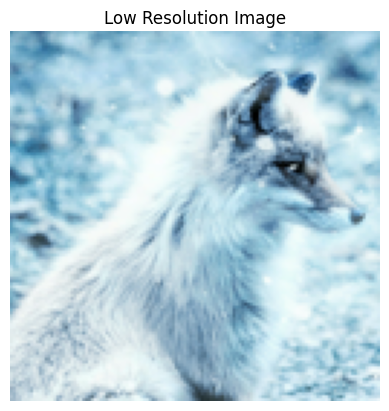

In [20]:
# Plotting Low Resolution Image
plot_image(tf.squeeze(lr_image),title='Low Resolution Image')

In [21]:
start = time.time()
fake_image = model(lr_image)
fake_image = tf.squeeze(fake_image)
print("Time Taken: %f" % (time.time() - start))

Time Taken: 2.163774


PSNR Achieved: 27.938789


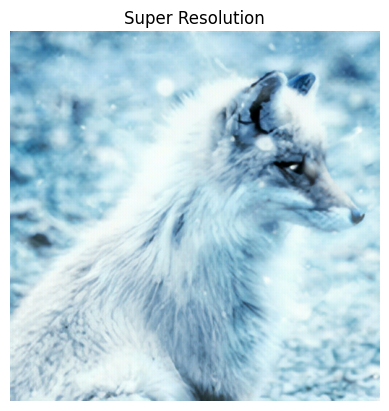

In [22]:
plot_image(tf.squeeze(fake_image), title="Super Resolution")
# Calculating PSNR wrt Original Image
psnr = tf.image.psnr(
    tf.clip_by_value(fake_image, 0, 255),
    tf.clip_by_value(hr_image, 0, 255), max_val=255)
print("PSNR Achieved: %f" % psnr)

- **Comparing Outputs size by side**

PSNR: 27.938789


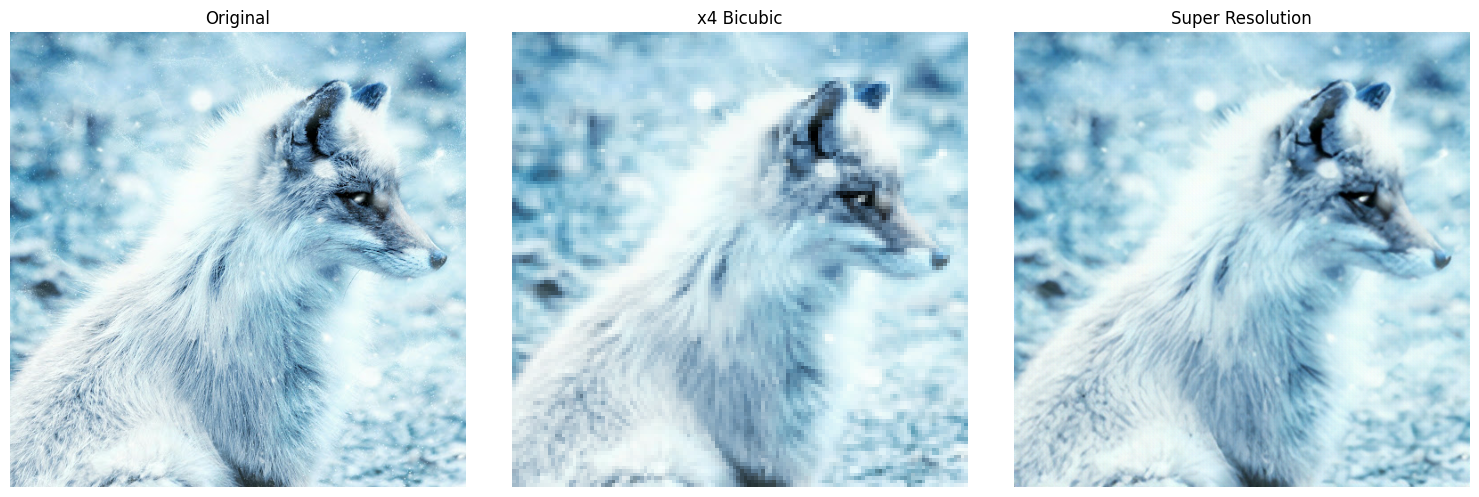

In [23]:
plt.rcParams['figure.figsize'] = [15, 10]
fig, axes = plt.subplots(1, 3)
fig.tight_layout()
plt.subplot(131)
plot_image(tf.squeeze(hr_image), title="Original")
plt.subplot(132)
fig.tight_layout()
plot_image(tf.squeeze(lr_image), "x4 Bicubic")
plt.subplot(133)
fig.tight_layout()
plot_image(tf.squeeze(fake_image), "Super Resolution")
plt.savefig("ESRGAN_DIV2K.jpg", bbox_inches="tight")
print("PSNR: %f" % psnr)